In [1]:
# Dirichlet‑Process clustering of NDVI time series
# Piece‑wise (Loredo‑style) temporal model
# PyMC implementation with truncated DP and sequential updating

import numpy as np
import pymc as pm
import pytensor.tensor as pt
from matplotlib import pyplot as plt

import scipy.stats as stats

In [2]:
N_SEGMENTS = 23

In [3]:
# ============================================================
# UTILITIES
# ============================================================

def doy_to_bin(doy, n_segments=N_SEGMENTS):
    """Map day-of-year to piecewise bin"""
    return np.floor((doy % 365) / 365 * n_segments).astype(int)

### levanto series NDVI

In [4]:
import pandas as pd

In [5]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [6]:
nSeries = 100

In [7]:
ndviDataStart = 7
testPixel = np.random.choice(df.shape[0], size=nSeries, replace=False)

### reconstruyo vector fechas

In [8]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])

### Incluyo fecha deforestacion

In [9]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

#### reordeno columna

In [10]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [12]:
df

,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,2000-03-21,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,0.327133,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,0.333600,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,0.336400,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,0.351067,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,0.351200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,0.291600,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,0.303000,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [13]:
ndviDataStart+=1

In [14]:
fechas.shape

(430,)

In [15]:
ndviDataStart

8

/tmp/ipykernel_84038/4001357351.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


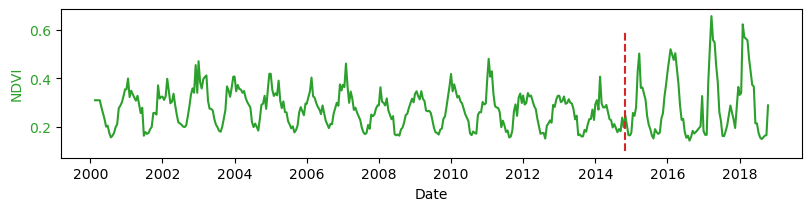

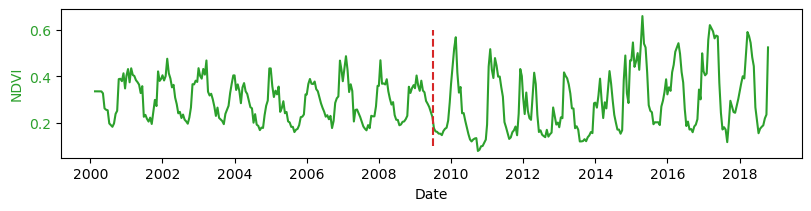

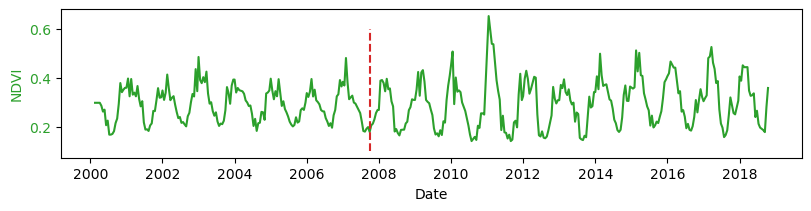

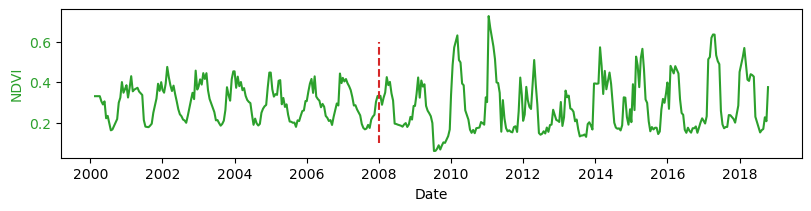

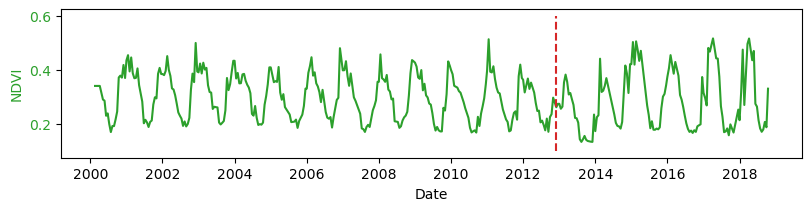

In [16]:
for pixel in testPixel[:5]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    ndvi = df.iloc[pixel, ndviDataStart-1:].values

    # plt.plot(fechas, ndvi)
    # plt.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
    # plt.show()

    fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    color1 = 'tab:green'
    color2 = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('NDVI', color=color1)
    ax1.plot(fechas, ndvi, color=color1)
    ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
    ax1.tick_params(axis='y', labelcolor=color1)

    fig.show()

### Separo bosque no bosque temporal!

In [17]:
pixel = testPixel[0]
deforestationDate = df['fechaDef'].iloc[pixel]
ndvi = df.iloc[pixel, ndviDataStart-1:].values

In [18]:
deforestationDate.to_julian_date()

2456962.5

In [19]:
fechas.to_julian_date()

Index([2451592.5, 2451608.5, 2451624.5, 2451640.5, 2451656.5, 2451672.5,
       2451688.5, 2451704.5, 2451720.5, 2451736.5,
       ...
       2458263.5, 2458279.5, 2458295.5, 2458311.5, 2458327.5, 2458343.5,
       2458359.5, 2458375.5, 2458391.5, 2458407.5],
      dtype='float64', length=430)

In [20]:
nSeriesToTrain = 30

In [21]:
series = []

ANIOS_ENTRENAMIENTO = 3

for pixel in testPixel[:nSeriesToTrain]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    # defIndex = np.argmax(fechas == deforestationDate)
    defIndex = np.argmin(np.abs(fechas.to_julian_date() - deforestationDate.to_julian_date()))
    
    firstJanIndex = np.argmax(fechas[defIndex:].month == 1) + defIndex #indice del primer enero después de la deforestación
    lastJanIndex = defIndex - np.argmax(np.flip(fechas[:defIndex].month == 1)) -1 #indice del ultimo enero antes de la deforestación

    # bosque = df.iloc[pixel, ndviDataStart-1:defIndex].values # todo el bosque
    bosque = df.iloc[pixel, lastJanIndex-(N_SEGMENTS*ANIOS_ENTRENAMIENTO):lastJanIndex].values # solo los tres años antes de la deforestación
    noBosque = df.iloc[pixel, firstJanIndex:firstJanIndex+(N_SEGMENTS*ANIOS_ENTRENAMIENTO)].values #segmento de tres años primer enero después de la deforestación

    if len(noBosque) < N_SEGMENTS*ANIOS_ENTRENAMIENTO:
        print(f"Advertencia: no hay suficientes datos después de la deforestación para el pixel {pixel}.")
        continue

    if len(bosque) < N_SEGMENTS*ANIOS_ENTRENAMIENTO:
        print(f"Advertencia: no hay suficientes datos antes de la deforestación para el pixel {pixel}.")
        continue
    
    if False:
        fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    series.append(bosque)
    series.append(noBosque)

    if False:
        color1 = 'tab:green'
        color2 = 'tab:red'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('NDVI', color=color1)
        ax1.plot(bosque, color=color1)
        ax1.plot(noBosque, color=color2)
        # ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
        ax1.tick_params(axis='y', labelcolor=color1)

        fig.show()

Advertencia: no hay suficientes datos después de la deforestación para el pixel 475.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 583.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 451.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 672.


In [22]:
quincenas = np.arange(0, 23*3)

In [23]:
quincenas.shape

(69,)

In [24]:
series = np.array(series)

In [25]:
series.shape

(52, 69)

In [26]:
#quincenas, series, true_clusters = synthetic_series(n_series=30, anios=3, sigma=SIGMA_MODIS)

In [27]:
# true_clusters 
true_clusters = [x%2 for x in range(series.shape[0])]

Text(0.5, 1.0, 'Series reales con clusters conocidos')

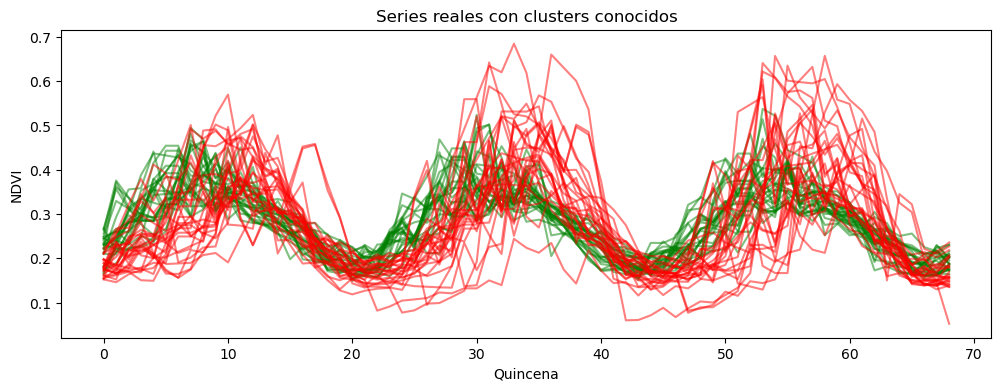

In [28]:
fig = plt.figure(figsize=(12,4))

plt.plot(quincenas, series[0::2, :].T, color='green', alpha=0.5)
plt.plot(quincenas, series[1::2, :].T, color='red', alpha=0.5)
plt.xlabel("Quincena")
plt.ylabel("NDVI")
plt.title("Series reales con clusters conocidos")

In [29]:
series = np.asarray(series, dtype=np.float32)

In [30]:
np.isnan(series).sum()

0

### Inferencia

In [31]:
def build_model_rw2_v0(Y):

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[None, :]

    N, T = Y.shape

    with pm.Model() as model:

        sigma_obs = pm.HalfNormal("sigma_obs", 0.05)
        sigma_rw = pm.HalfNormal("sigma_rw", 0.05)

        # ruido base
        eps = pm.GaussianRandomWalk(
            "eps",
            sigma=sigma_rw,
            shape=(N, T)
        )

        # integración 2 veces → RW2
        x = pm.Deterministic(
            "x",
            eps.cumsum(axis=1).cumsum(axis=1)
        )

        pm.Normal(
            "y",
            mu=x,
            sigma=sigma_obs,
            observed=Y
        )

    return model

In [32]:

def build_model_rw2(Y):
    """
    RW2 temporal model for NDVI time series.

    Parameters
    ----------
    Y : array-like
        shape (T,) or (N_series, T)

    Returns
    -------
    PyMC model
    """

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[None, :]

    N, T = Y.shape

    with pm.Model() as model:

        # ----- Observation noise -----
        sigma_obs = pm.HalfNormal("sigma_obs", 0.05)

        # ----- RW innovation scale -----
        sigma_rw = pm.HalfNormal("sigma_rw", 0.1)

        # ----- Mean NDVI level (controls drift) -----
        mu = pm.Normal("mu", 0.5, 0.3, shape=N)

        # ----- Latent RW increments -----
        eps = pm.GaussianRandomWalk(
            "eps",
            sigma=sigma_rw,
            shape=(N, T)
        )

        # ----- RW2 (double integration) -----
        z = pm.Deterministic(
            "z",
            mu[:, None] + eps.cumsum(axis=1).cumsum(axis=1)
        )

        # ----- Transform to NDVI space -----
        ndvi = pm.Deterministic(
            "ndvi",
            pm.math.sigmoid(z)
        )

        # ----- Likelihood -----
        pm.Normal(
            "y",
            mu=ndvi,
            sigma=sigma_obs,
            observed=Y
        )

    return model

### pruebo con series conocidas

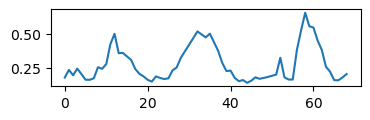

In [51]:
plt.figure(figsize=(4,1))
plt.plot(series[1])
serie_prueba = series[0]

In [ ]:
model = build_model_rw2(serie_prueba)

In [58]:
for rv in model.free_RVs:
    print(rv.name, rv.eval().shape)

sigma_obs ()
sigma_rw ()
mu (1,)
eps (1, 69)


In [ ]:

with model:
    idata = pm.sample(
        1000,
        tune=500,
        target_accept=0.9
    )

/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pymc/distributions/timeseries.py:298: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_obs, sigma_rw, mu, eps]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 106 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [59]:
import arviz as az
# az.summary(trace, var_names=["z"])
az.summary(idata)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[0],-0.955,0.110,-1.158,-0.749,0.004,0.002,992.0,1754.0,1.00
"eps[0, 0]",-0.024,0.039,-0.099,0.045,0.002,0.001,512.0,840.0,1.01
"eps[0, 1]",0.005,0.025,-0.042,0.052,0.001,0.001,1695.0,1957.0,1.00
"eps[0, 2]",0.034,0.028,-0.017,0.089,0.001,0.001,1490.0,1127.0,1.00
"eps[0, 3]",0.051,0.031,-0.002,0.112,0.001,0.001,1018.0,1246.0,1.00
...,...,...,...,...,...,...,...,...,...
"ndvi[0, 64]",0.192,0.012,0.170,0.214,0.000,0.000,1550.0,2305.0,1.00
"ndvi[0, 65]",0.174,0.012,0.152,0.197,0.000,0.000,1098.0,2578.0,1.00
"ndvi[0, 66]",0.165,0.012,0.143,0.187,0.000,0.000,1640.0,2939.0,1.00
"ndvi[0, 67]",0.164,0.013,0.138,0.187,0.000,0.000,3970.0,3628.0,1.00


In [60]:
idata.posterior

<xarray.Dataset> Size: 7MB
Dimensions:     (chain: 4, draw: 1000, mu_dim_0: 1, eps_dim_0: 1,
                 eps_dim_1: 69, z_dim_0: 1, z_dim_1: 69, ndvi_dim_0: 1,
                 ndvi_dim_1: 69)
Coordinates:
  * chain       (chain) int64 32B 0 1 2 3
  * draw        (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * mu_dim_0    (mu_dim_0) int64 8B 0
  * eps_dim_0   (eps_dim_0) int64 8B 0
  * eps_dim_1   (eps_dim_1) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
  * z_dim_0     (z_dim_0) int64 8B 0
  * z_dim_1     (z_dim_1) int64 552B 0 1 2 3 4 5 6 7 ... 61 62 63 64 65 66 67 68
  * ndvi_dim_0  (ndvi_dim_0) int64 8B 0
  * ndvi_dim_1  (ndvi_dim_1) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
Data variables:
    mu          (chain, draw, mu_dim_0) float64 32kB -1.065 -0.8195 ... -0.8114
    eps         (chain, draw, eps_dim_0, eps_dim_1) float64 2MB -0.001912 ......
    sigma_obs   (chain, draw) float64 32kB 0.03018 0.01826 ... 0.02374 0.01604
    sigma_rw    (chain, draw) float64 32kB 0.05823 0.04672 ... 0.05628 0.06629
    z           (chain, draw, z_dim_0, z_dim_1) float64 2MB -1.067 ... -1.615
    ndvi        (chain, draw, ndvi_dim_0, ndvi_dim_1) float64 2MB 0.256 ... 0...
Attributes:
    created_at:                 2026-03-05T19:00:45.186566+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.12.0
    sampling_time:              106.19627976417542
    tuning_steps:               500

reconstruyo la serie

In [53]:
est = idata.posterior["ndvi"].mean(dim=["chain", "draw"])

In [54]:
est.values[0]

array([0.27342443, 0.2695294 , 0.27246359, 0.28564013, 0.31024947,
       0.3453701 , 0.3840234 , 0.41156121, 0.41556553, 0.39607136,
       0.36084142, 0.32247713, 0.28931351, 0.26267968, 0.24055704,
       0.22135093, 0.20491711, 0.19077083, 0.1798259 , 0.17405029,
       0.17556288, 0.18624956, 0.20627936, 0.23294933, 0.26075384,
       0.2848724 , 0.30310443, 0.31339969, 0.3165119 , 0.31607928,
       0.3156659 , 0.31816488, 0.32255871, 0.32443232, 0.32003695,
       0.30722889, 0.286283  , 0.25971383, 0.23118955, 0.20521688,
       0.18553201, 0.17392626, 0.17041925, 0.17467717, 0.1858696 ,
       0.20213457, 0.22206405, 0.24485812, 0.26889343, 0.29065038,
       0.30739964, 0.3170998 , 0.31959655, 0.31725821, 0.31364659,
       0.31060799, 0.30846791, 0.30733969, 0.30522177, 0.29892765,
       0.2861639 , 0.26649629, 0.24183256, 0.21578362, 0.19197865,
       0.17436904, 0.16470482, 0.16380978, 0.17275911])

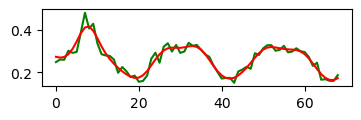

In [55]:
plt.figure(figsize=(4,1))
plt.plot(series[0],'g')
plt.plot(est.values[0],'r')

Clusterizo todas las series

In [61]:
def build_model_dp_rw2(series_values,
                       MAX_CLUSTERS=6,
                       ALPHA_DP=1.0):

    """
    DP clustering de series de tiempo con modelo temporal RW2 por cluster
    """

    series_values = np.asarray(series_values)

    n_series, T = series_values.shape

    with pm.Model() as model:

        # -----------------------------
        # Stick breaking DP
        # -----------------------------

        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pm.math.concatenate(
                [beta[:1],
                 beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])]
            )
        )

        pi = pi / pi.sum()

        # -----------------------------
        # cluster assignment
        # -----------------------------

        z = pm.Categorical("z", p=pi, shape=n_series)

        # -----------------------------
        # cluster parameters
        # -----------------------------

        mu = pm.Normal("mu", 0.5, 0.5, shape=MAX_CLUSTERS)

        sigma_rw = pm.HalfNormal("sigma_rw", 0.2, shape=MAX_CLUSTERS)

        sigma_obs = pm.HalfNormal("sigma_obs", 0.1, shape=MAX_CLUSTERS)

        # -----------------------------
        # RW2 per cluster
        # -----------------------------

        eps = pm.Normal(
            "eps",
            0,
            sigma_rw[:, None],
            shape=(MAX_CLUSTERS, T-1)
        )

        rw1 = pt.cumsum(eps, axis=1)
        rw2 = pt.cumsum(rw1, axis=1)

        x = pt.concatenate(
            [mu[:, None], mu[:, None] + rw2],
            axis=1
        )

        x = pm.Deterministic("x", x)

        # -----------------------------
        # likelihood
        # -----------------------------

        for i in range(n_series):

            mu_i = x[z[i]]

            pm.Normal(
                f"y_{i}",
                mu=mu_i,
                sigma=sigma_obs[z[i]],
                observed=series_values[i]
            )

    return model

In [103]:
def build_model_dp_rw2_vectorized(series_values,
                                  MAX_CLUSTERS=6,
                                  ALPHA_DP=1.0):

    series_values = np.asarray(series_values)

    n_series, T = series_values.shape

    with pm.Model() as model:

        # -----------------------------
        # Stick-breaking DP
        # -----------------------------

        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pt.concatenate(
                [
                    beta[:1],
                    beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])
                ]
            )
        )

        pi = pi / pi.sum()

        # -----------------------------
        # cluster assignments
        # -----------------------------

        z = pm.Categorical("z", p=pi, shape=n_series)

        # -----------------------------
        # cluster parameters
        # -----------------------------

        mu = pm.Normal("mu", 0.5, 0.5, shape=MAX_CLUSTERS)

        sigma_rw = pm.HalfNormal("sigma_rw", 0.2, shape=MAX_CLUSTERS)

        sigma_obs = pm.HalfNormal("sigma_obs", 0.1, shape=MAX_CLUSTERS)

        # -----------------------------
        # RW2 temporal process
        # -----------------------------

        eps = pm.Normal(
            "eps",
            0,
            sigma_rw[:, None],
            shape=(MAX_CLUSTERS, T - 1)
        )

        rw1 = pt.cumsum(eps, axis=1)
        rw2 = pt.cumsum(rw1, axis=1)

        # version unbounded ------------------------------------
        # x = pt.concatenate([mu[:, None], mu[:, None] + rw2],axis=1)
        # x = pm.Deterministic("x", x)

        # version bounded ------------------------------------
        eta = pt.concatenate([mu[:, None], mu[:, None] + rw2],axis=1)
        x = pm.Deterministic("x", pm.math.sigmoid(eta))

        # -----------------------------
        # select cluster trajectory
        # -----------------------------

        mu_series = x[z]              # shape (n_series, T)
        sigma_series = sigma_obs[z]   # shape (n_series,)

        # -----------------------------
        # likelihood vectorizada
        # -----------------------------

        pm.Normal(
            "y",
            mu=mu_series,
            sigma=sigma_series[:, None],
            observed=series_values
        )

    return model

In [104]:
series.shape

(52, 69)

In [121]:
# clusterModel = build_model_dp_rw2(series)
clusterModel = build_model_dp_rw2_vectorized(series,
                                  MAX_CLUSTERS=5,
                                  ALPHA_DP=3.0)

In [122]:
for rv in clusterModel.free_RVs:
    print(rv.name, rv.eval().shape)

beta (5,)
z (52,)
mu (5,)
sigma_rw (5,)
sigma_obs (5,)
eps (5, 68)


In [123]:
with clusterModel:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [beta, mu, sigma_rw, sigma_obs, eps]
>CategoricalGibbsMetropolis: [z]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 398 seconds.
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some 

In [124]:
import arviz as az
# az.summary(trace, var_names=["z"])
az.summary(trace, var_names=["sigma_rw", "sigma_obs", "mu"])

# az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_rw[0],0.051,0.008,0.038,0.065,0.001,0.001,147.0,179.0,1.03
sigma_rw[1],0.020,0.026,0.000,0.071,0.013,0.007,5.0,12.0,2.64
sigma_rw[2],0.028,0.024,0.001,0.073,0.010,0.005,5.0,28.0,1.98
sigma_rw[3],0.027,0.025,0.000,0.071,0.012,0.005,5.0,13.0,2.02
sigma_rw[4],0.028,0.022,0.000,0.067,0.008,0.003,9.0,30.0,1.37
sigma_obs[0],0.046,0.013,0.036,0.067,0.006,0.002,7.0,18.0,1.57
sigma_obs[1],0.077,0.052,0.000,0.175,0.002,0.007,201.0,114.0,1.49
sigma_obs[2],0.067,0.050,0.000,0.166,0.007,0.007,274.0,287.0,1.29
sigma_obs[3],0.077,0.049,0.000,0.166,0.002,0.007,436.0,303.0,1.42
sigma_obs[4],0.081,0.057,0.000,0.181,0.002,0.004,437.0,491.0,1.24


In [125]:
trace.posterior

<xarray.Dataset> Size: 49MB
Dimensions:          (chain: 4, draw: 2000, z_dim_0: 52, mu_dim_0: 5,
                      eps_dim_0: 5, eps_dim_1: 68, beta_dim_0: 5,
                      sigma_rw_dim_0: 5, sigma_obs_dim_0: 5, pi_dim_0: 5,
                      x_dim_0: 5, x_dim_1: 69)
Coordinates:
  * chain            (chain) int64 32B 0 1 2 3
  * draw             (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
  * z_dim_0          (z_dim_0) int64 416B 0 1 2 3 4 5 6 ... 45 46 47 48 49 50 51
  * mu_dim_0         (mu_dim_0) int64 40B 0 1 2 3 4
  * eps_dim_0        (eps_dim_0) int64 40B 0 1 2 3 4
  * eps_dim_1        (eps_dim_1) int64 544B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67
  * beta_dim_0       (beta_dim_0) int64 40B 0 1 2 3 4
  * sigma_rw_dim_0   (sigma_rw_dim_0) int64 40B 0 1 2 3 4
  * sigma_obs_dim_0  (sigma_obs_dim_0) int64 40B 0 1 2 3 4
  * pi_dim_0         (pi_dim_0) int64 40B 0 1 2 3 4
  * x_dim_0          (x_dim_0) int64 40B 0 1 2 3 4
  * x_dim_1          (x_dim_1) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
Data variables:
    z                (chain, draw, z_dim_0) int64 3MB 0 0 0 0 0 0 ... 3 0 3 0 3
    mu               (chain, draw, mu_dim_0) float64 320kB -1.262 ... 0.7193
    eps              (chain, draw, eps_dim_0, eps_dim_1) float64 22MB 0.07715...
    beta             (chain, draw, beta_dim_0) float64 320kB 0.9472 ... 0.05335
    sigma_rw         (chain, draw, sigma_rw_dim_0) float64 320kB 0.04363 ... ...
    sigma_obs        (chain, draw, sigma_obs_dim_0) float64 320kB 0.06833 ......
    pi               (chain, draw, pi_dim_0) float64 320kB 0.9472 ... 0.006578
    x                (chain, draw, x_dim_0, x_dim_1) float64 22MB 0.2207 ... ...
Attributes:
    created_at:                 2026-03-05T20:39:31.166085+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.12.0
    sampling_time:              397.6710968017578
    tuning_steps:               1000

In [126]:
z_post = trace.posterior["z"].mean(dim=("chain","draw")).values
z_est = np.round(z_post).astype(int)

In [127]:
print("True clusters:")
print(true_clusters)
print("Estimated clusters:")
print(z_est)
print("Estimated N:", len(np.unique(z_est)))

True clusters:
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
Estimated clusters:
[0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]
Estimated N: 2


### Evaluacion clusters

In [128]:
# import numpy as np
# import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def aligned_confusion(true_labels, est_labels):
    true_labels = np.array(true_labels)
    est_labels  = np.array(est_labels)

    cm = confusion_matrix(true_labels, est_labels)

    # Hungarian algorithm → maximizar diagonal
    row_ind, col_ind = linear_sum_assignment(-cm)

    aligned_cm = cm[:, col_ind]
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}

    aligned_est = np.array([mapping[e] for e in est_labels])

    return aligned_cm, aligned_est, mapping


In [129]:
def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Estimated cluster")
    plt.ylabel("True cluster")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j],
                     ha="center", va="center",
                     fontsize=12)

    plt.tight_layout()
    plt.show()


In [130]:
uniques = np.unique(z_est)

In [131]:
# z_est[z_est == 4] = 3

Cluster mapping: {0: 0, 2: 1, 1: 2}


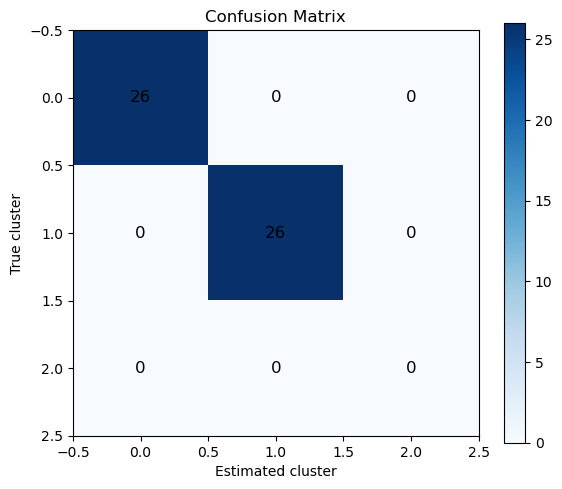

In [132]:
cm, aligned_est, mapping = aligned_confusion(true_clusters, z_est)

print("Cluster mapping:", mapping)
plot_confusion(cm)


Evaluacion series de tiempo

In [133]:
def extract_cluster_signatures(trace, z_est):

    x_post = trace.posterior["x"]

    # media posterior
    x_mean = x_post.mean(dim=("chain","draw")).values

    # desviación estándar posterior
    x_std = x_post.std(dim=("chain","draw")).values

    # tamaño de clusters
    clusters = np.unique(z_est)
    cluster_size = {k: np.sum(z_est == k) for k in clusters}

    signatures = {}

    for k in clusters:

        signatures[k] = {
            "mean": x_mean[k],
            "std": x_std[k],
            "size": cluster_size[k]
        }

    return signatures

In [143]:
# import matplotlib.pyplot as plt

def plot_cluster_signatures(signatures):

    for k, s in signatures.items():

        mu = s["mean"]
        sd = s["std"]
        n  = s["size"]

        t = np.arange(len(mu))

        plt.plot(t, mu, label=f"cluster {k} (n={n})")

        plt.fill_between(
            t,
            mu - 1*sd,
            mu + 1*sd,
            alpha=0.2
        )

    plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.2)
    plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.2)

    plt.ylim(0.1, 0.6)
    plt.xlabel("time")
    plt.ylabel("NDVI")
    plt.legend()
    plt.show()

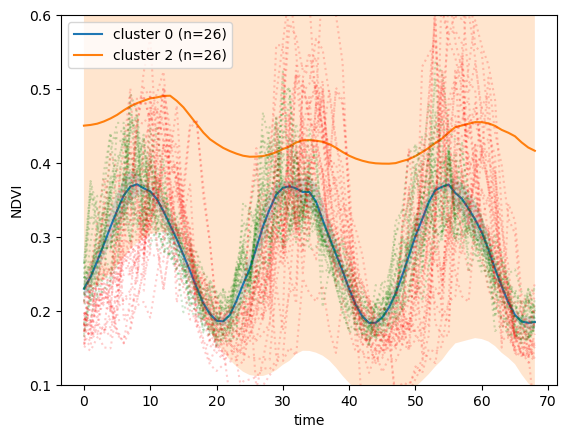

In [144]:
signatures = extract_cluster_signatures(trace, z_est)

plot_cluster_signatures(signatures)

In [73]:
def plot_cluster_ndvi_posterior(trace, z_est, ci=0.9):
    """
    trace   : trace de PyMC
    z_est   : cluster asignado por serie
    """

    a_post = trace.posterior["a"].stack(sample=("chain","draw")).values
    # shape = (Kmax, N_segments, n_samples)

    clusters = np.unique(z_est)
    # bins = np.floor((days % 365) / 365 * n_segments).astype(int)

    plt.figure(figsize=(10,4))
    
    for k in clusters:

        samples = a_post[k, quincenas[:23], :]  # (365, n_samples)

        mean = samples.mean(axis=1)
        low  = np.percentile(samples, (1-ci)/2*100, axis=1)
        high = np.percentile(samples, (1+(ci))/2*100, axis=1)

        n_series = np.sum(z_est == k)

        plt.plot(quincenas[:23], mean, label=f"Cluster {k} (n={n_series})")
        plt.fill_between(quincenas[:23], low, high, alpha=0.25)

    # series reales
    # plt.plot(quincenas[:23], series[true_clusters, :23].mean(axis=0), color='green', alpha=0.5, label="Bosque medio")
    # plt.plot(quincenas[:23], series[true_clusters == 1, :].T[:23], color='red', alpha=0.1)
    # plt.plot(quincenas[:23], series[true_clusters == 2, :].T[:23], color='blue', alpha=0.1)

    #Este anda!
    # plt.plot(quincenas, series[0::2, :23].mean(axis=0), linestyle=':', color='green', alpha=0.5, label="Bosque medio")
    # plt.plot(quincenas, series[1::2, :23].mean(axis=0), linestyle=':', color='red', alpha=0.5, label="No Bosque medio")

    plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.1) #, label="Bosque medio"
    plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.1) #, label="No Bosque medio"

    plt.xlim(0, 23)
    plt.ylim(0.1, 0.6)

    plt.xlabel("Quincena")
    plt.ylabel("NDVI")
    plt.title("NDVI promedio por cluster (posterior PyMC)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [74]:
plot_cluster_ndvi_posterior(trace, z_est, ci=0.9)

KeyError: "No variable named 'a'. Variables on the dataset include ['chain', 'draw', 'z_dim_0', 'z', 'mu_dim_0', ..., 'pi_dim_0', 'pi', 'x_dim_0', 'x_dim_1', 'x']"

In [ ]:
series[true_clusters, :23].mean(axis=0)

In [ ]:
series[1::2, :23].shape

In [ ]:
plt.plot(quincenas[:23], series[1::2, :23].mean(axis=0), linestyle=':', color='red', alpha=0.5, label="No Bosque medio")


In [ ]:
quincenas.shape

In [ ]:
plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.5, label="Bosque medio")
plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.5, label="No Bosque medio")